<a href="https://colab.research.google.com/github/Mazen-Morsy/ML-Final/blob/main/Heart_Disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [138]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [139]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , f1_score, precision_score, recall_score

In [140]:
df = pd.read_csv("/content/heart_patients_dirty_dataset.csv")


In [141]:
df.head()

,Patient_ID,Age,Gender,Chest_Pain_Type,Resting_BP_mmHg,Cholesterol_mg/dl,Max_Heart_Rate,ST_Depression,Exercise_Induced_Angina,Heart_Disease
0,524.0,87.0,NaN,NaN,151.343081,162.378238,162.287641,2.801430,Yes,zero
1,603.0,66.0,male,NaN,101.214098,218.380992,155.846201,0.182318,No,zero
2,527.0,87.0,FEMALE,Atypical Angina,150.354093,248.765623,195.335192,0.875113,yes,1
3,32.0,87.0,FEMALE,Non-Anginal Pain,124.865389,NaN,180.730370,0.300505,yes,NaN
4,617.0,45.0,NaN,Typical Angina,112.437303,211.572296,121.968906,NaN,No,one


In [142]:
df.shape

(1020, 10)

In [143]:
df.isnull().mean()*100

,0
Patient_ID,1.470588
Age,1.470588
Gender,21.176471
Chest_Pain_Type,21.764706
Resting_BP_mmHg,1.568627
Cholesterol_mg/dl,1.470588
Max_Heart_Rate,1.568627
ST_Depression,2.450980
Exercise_Induced_Angina,21.470588
Heart_Disease,23.333333


In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               1005 non-null   float64
 1   Age                      1005 non-null   object 
 2   Gender                   804 non-null    object 
 3   Chest_Pain_Type          798 non-null    object 
 4   Resting_BP_mmHg          1004 non-null   float64
 5   Cholesterol_mg/dl        1005 non-null   float64
 6   Max_Heart_Rate           1004 non-null   float64
 7   ST_Depression            995 non-null    float64
 8   Exercise_Induced_Angina  801 non-null    object 
 9   Heart_Disease            782 non-null    object 
dtypes: float64(5), object(5)
memory usage: 79.8+ KB


In [145]:
df.describe()

,Patient_ID,Resting_BP_mmHg,Cholesterol_mg/dl,Max_Heart_Rate,ST_Depression
count,1005.000000,1004.000000,1005.000000,1004.000000,995.000000
mean,501.477612,121.967621,208.588632,149.889774,0.988759
std,288.663393,18.300116,85.665783,26.977657,0.989915
min,1.000000,74.707318,50.443201,74.809192,-2.176704
25%,255.000000,110.589693,164.548952,132.826732,0.343811
50%,501.000000,120.502121,201.722051,149.947067,0.982994
75%,752.000000,130.897693,234.770124,166.470884,1.655162
max,1000.000000,237.905224,976.733483,297.129217,4.112910


In [146]:
df.describe(include='object')

,Age,Gender,Chest_Pain_Type,Exercise_Induced_Angina,Heart_Disease
count,1005,804,798,801,782
unique,61,4,4,4,4
top,87.0,male,Asymptomatic,Yes,zero
freq,28,212,225,236,207


In [147]:
categorical_cols=list(df.select_dtypes(include=object).columns)
categorical_cols

['Age',
 'Gender',
 'Chest_Pain_Type',
 'Exercise_Induced_Angina',
 'Heart_Disease']

In [148]:
numerical_cols=list(df.select_dtypes(include=np.number).columns)
numerical_cols

['Patient_ID',
 'Resting_BP_mmHg',
 'Cholesterol_mg/dl',
 'Max_Heart_Rate',
 'ST_Depression']

In [149]:
df['Gender'].unique()

array([nan, 'male', 'FEMALE', 'Male', 'Female'], dtype=object)

In [150]:
df['Gender'] = df['Gender' ].str.strip()
df['Gender'] = df['Gender'].str. lower()
df['Gender'].unique()


array([nan, 'male', 'female'], dtype=object)

In [151]:
df[ 'Chest_Pain_Type'].unique()

array([nan, 'Atypical Angina', 'Non-Anginal Pain', 'Typical Angina',
       'Asymptomatic'], dtype=object)

In [152]:
df[ 'Exercise_Induced_Angina'].unique()

array(['Yes', 'No', 'yes', nan, 'NO'], dtype=object)

In [153]:
df['Exercise_Induced_Angina'] = df['Exercise_Induced_Angina' ].str.strip()
df['Exercise_Induced_Angina'] = df['Exercise_Induced_Angina'].str.lower()
df['Exercise_Induced_Angina'].unique()


array(['yes', 'no', nan], dtype=object)

In [154]:
df['Heart_Disease'].unique()

array(['zero', '1', nan, 'one', '0'], dtype=object)

In [155]:
# print(df.shape)
# print(df['Heart_Disease'].value_counts(dropna=False))

In [156]:
df['Heart_Disease'] = df['Heart_Disease'].replace({'zero':'0' , 'one':'1'})
df['Heart_Disease'] = pd.to_numeric(df['Heart_Disease'], errors='coerce') #converting heart disease from object to numeric
df['Heart_Disease'].unique()

array([ 0.,  1., nan])

In [157]:
# print(df.shape)
# print(df['Heart_Disease'].value_counts(dropna=False))

In [158]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce') #converting object from object to numeric

In [159]:
df.drop(columns=['Patient_ID'],inplace=True)

In [160]:
df.describe()

,Age,Resting_BP_mmHg,Cholesterol_mg/dl,Max_Heart_Rate,ST_Depression,Heart_Disease
count,995.000000,1004.000000,1005.000000,1004.000000,995.000000,782.000000
mean,60.128643,121.967621,208.588632,149.889774,0.988759,0.514066
std,17.419188,18.300116,85.665783,26.977657,0.989915,0.500122
min,30.000000,74.707318,50.443201,74.809192,-2.176704,0.000000
25%,45.500000,110.589693,164.548952,132.826732,0.343811,0.000000
50%,61.000000,120.502121,201.722051,149.947067,0.982994,1.000000
75%,76.000000,130.897693,234.770124,166.470884,1.655162,1.000000
max,89.000000,237.905224,976.733483,297.129217,4.112910,1.000000


In [161]:
numerical_cols=list(df.select_dtypes(include=np.number).columns)
numerical_cols

['Age',
 'Resting_BP_mmHg',
 'Cholesterol_mg/dl',
 'Max_Heart_Rate',
 'ST_Depression',
 'Heart_Disease']

In [162]:
df[df['ST_Depression'] < 0]['ST_Depression'].value_counts()

,count
ST_Depression,
-0.271919,2
-0.445205,2
-0.064220,2
-0.497258,2
-0.130179,2
...,...
-0.055108,1
-0.290561,1
-0.190408,1


In [163]:
df['Age'] = df['Age'].fillna(df['Age'].mean()) #replacing the none values of age with the mean

In [164]:
df['Age'] = df['Age'].fillna(df['Age'].mean()) #replacing the none values of age with the mean

In [165]:
df['Resting_BP_mmHg'] = df['Resting_BP_mmHg'].fillna(df['Resting_BP_mmHg'].median()) #replacing the none values with the median

In [166]:
df['Cholesterol_mg/dl'] = df['Cholesterol_mg/dl'].fillna(df['Cholesterol_mg/dl'].median()) #replacing the none values with the median

In [167]:
df['Max_Heart_Rate'] = df['Max_Heart_Rate'].fillna(df['Max_Heart_Rate'].median()) #replacing the none values with the median

In [168]:
df['ST_Depression'] = df['ST_Depression'].fillna(df['ST_Depression'].median()) #replacing the none values with the median

In [169]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0]) #replacing the none values with the mode 3l4an categorical

In [170]:
df['Chest_Pain_Type'] = df['Chest_Pain_Type'].fillna(df['Chest_Pain_Type'].mode()[0]) #replacing the none values with the mode 3l4an categorical

In [171]:
df['Exercise_Induced_Angina'] = df['Exercise_Induced_Angina'].fillna(df['Exercise_Induced_Angina'].mode()[0]) #replacing the none values with the mode 3l4an categorical

In [172]:
print(df.shape)
print(df['Heart_Disease'].value_counts(dropna=False))

(1020, 9)
Heart_Disease
1.0    402
0.0    380
NaN    238
Name: count, dtype: int64


In [173]:
df = df.dropna(subset=['Heart_Disease']) #dropping the none values of heart disease (target)

In [174]:
print(df.shape)
print(df['Heart_Disease'].value_counts(dropna=False))

(782, 9)
Heart_Disease
1.0    402
0.0    380
Name: count, dtype: int64


In [175]:
df['Heart_Disease'].value_counts() # balanced

,count
Heart_Disease,
1.0,402
0.0,380


In [176]:
df.isnull().sum()

,0
Age,0
Gender,0
Chest_Pain_Type,0
Resting_BP_mmHg,0
Cholesterol_mg/dl,0
Max_Heart_Rate,0
ST_Depression,0
Exercise_Induced_Angina,0
Heart_Disease,0


In [177]:
df.duplicated().sum()


np.int64(13)

In [178]:
df = df.drop_duplicates()

In [179]:
df.duplicated().sum()

np.int64(0)

In [180]:
len(df['Cholesterol_mg/dl'])

769

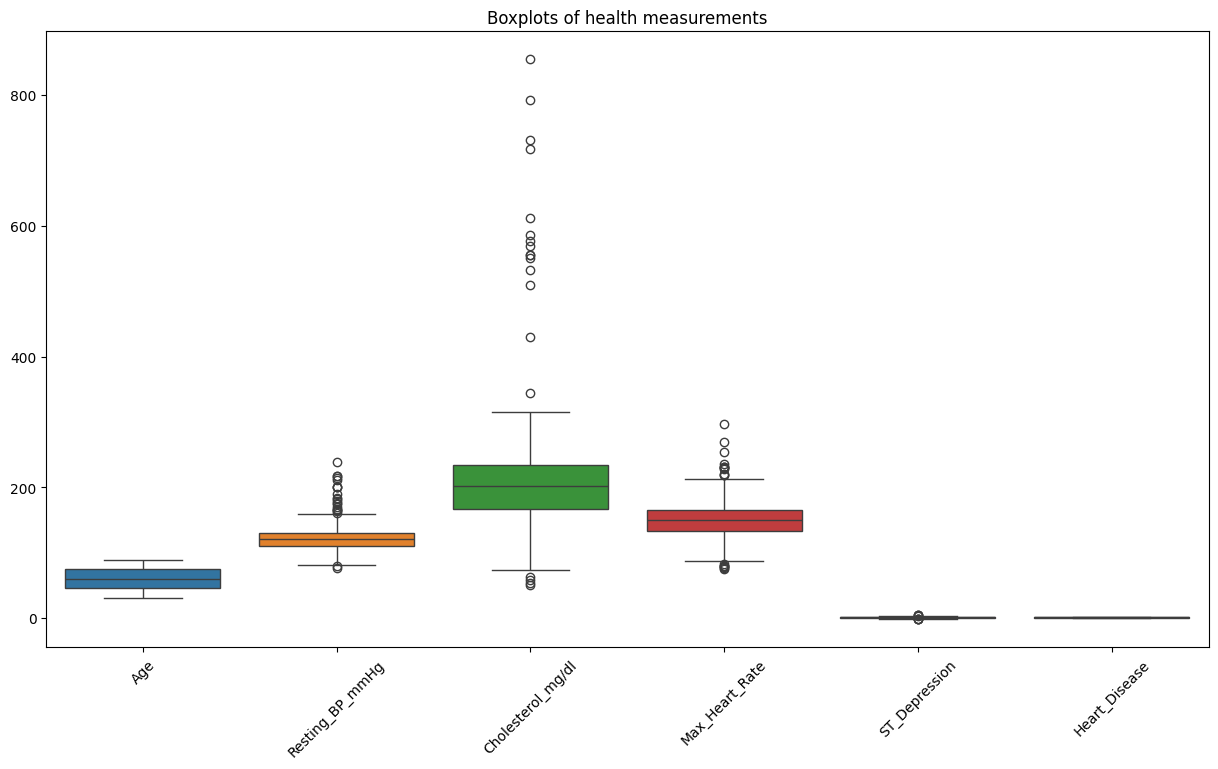

In [181]:
#outlier detection
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.title('Boxplots of health measurements')

plt.show()

In [182]:
len(df[df['Cholesterol_mg/dl'] > 600]['Cholesterol_mg/dl']) # bnshof 3dd el outliers

5

In [183]:
len(df['Cholesterol_mg/dl'])

769

In [184]:
df = df[df['Cholesterol_mg/dl'] < 600] # removing outliers

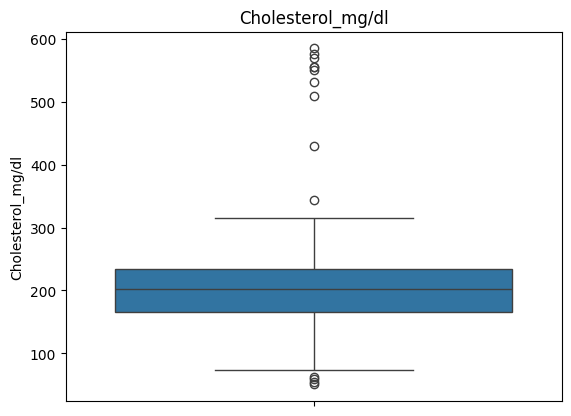

In [185]:
sns.boxplot(df['Cholesterol_mg/dl'])
plt.title('Cholesterol_mg/dl')
plt.show()

In [186]:
len(df[df['Max_Heart_Rate'] > 250]['Max_Heart_Rate']) # bnshof 3dd el outliers

2

In [187]:
len(df['Max_Heart_Rate'])

764

In [188]:
df = df[df['Max_Heart_Rate'] < 250] # removing outliers

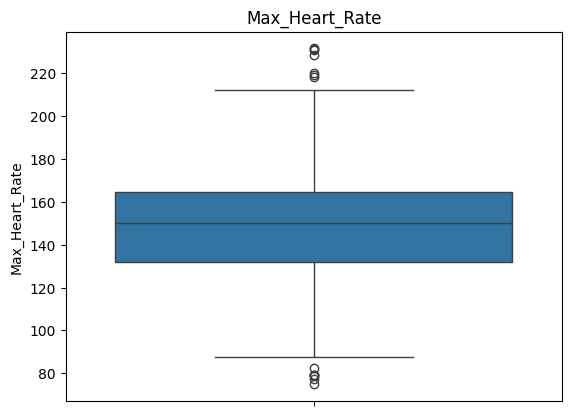

In [189]:
sns.boxplot(df['Max_Heart_Rate'])
plt.title('Max_Heart_Rate')
plt.show()

In [190]:
len(df[df['Resting_BP_mmHg'] > 220]['Resting_BP_mmHg']) # bnshof 3dd el outliers

1

In [191]:
len(df['Resting_BP_mmHg'])

762

In [192]:
df = df[df['Resting_BP_mmHg'] < 220] # removing outliers

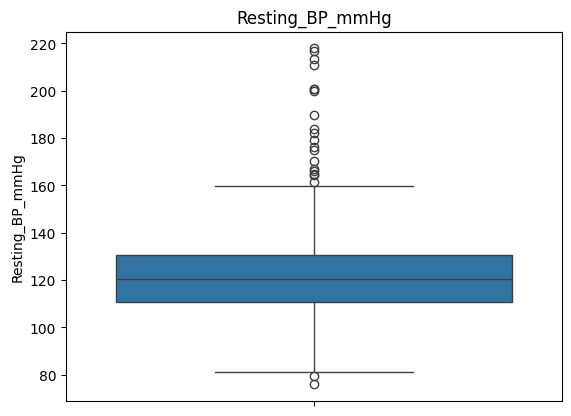

In [193]:
sns.boxplot(df['Resting_BP_mmHg'])
plt.title('Resting_BP_mmHg')
plt.show()

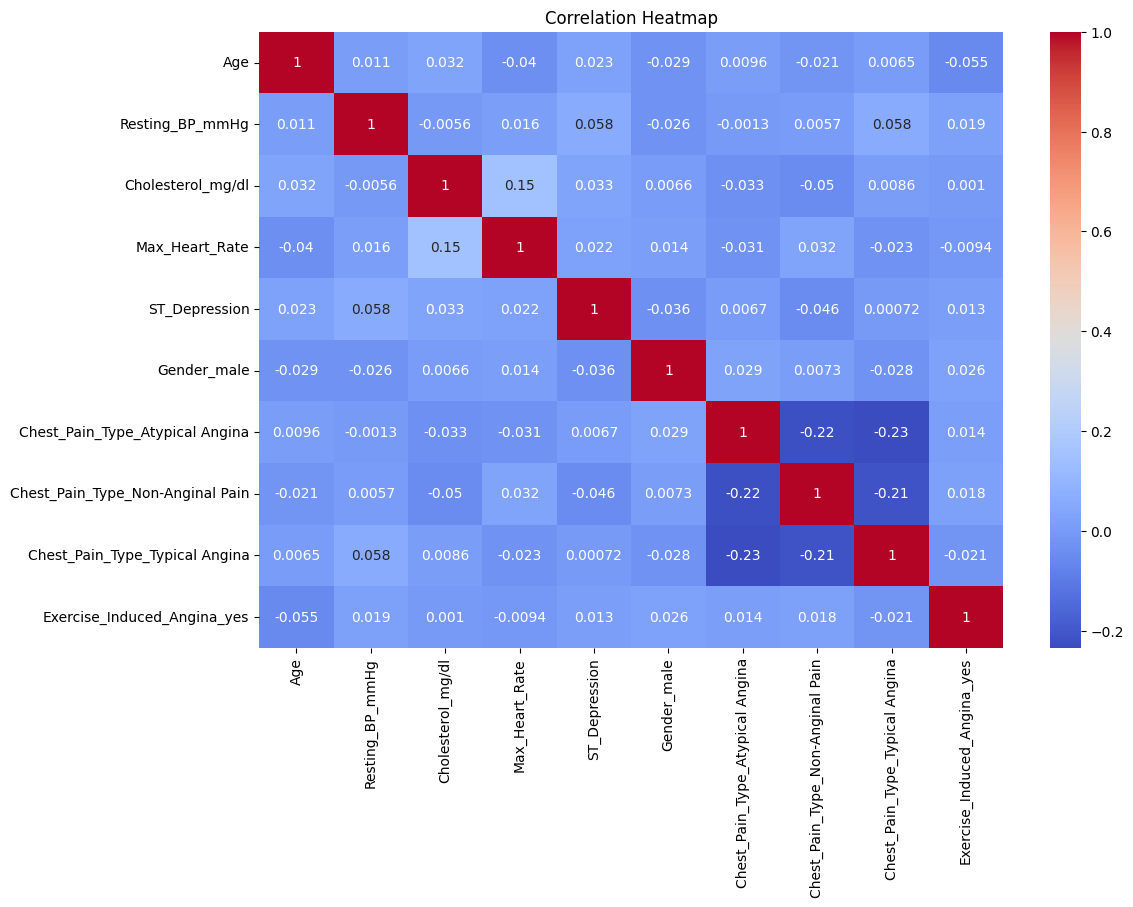

In [194]:
corr = X_encoded.corr()
plt.figure(figsize=(12, 8))  # el heat map

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

preprocessing

In [195]:
X = df.drop(columns=["Heart_Disease"])
y = df["Heart_Disease"]

In [196]:
cat_cols = ["Gender", "Chest_Pain_Type", "Exercise_Induced_Angina"]
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [197]:
num_cols = [
    "Age",
    "Resting_BP_mmHg",
    "Cholesterol_mg/dl",
    "Max_Heart_Rate",
    "ST_Depression",
]

In [198]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y) # we used stratify to keep the data balanced


In [199]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

In [200]:
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])
X_train_scaled

,Age,Resting_BP_mmHg,Cholesterol_mg/dl,Max_Heart_Rate,ST_Depression,Gender_male,Chest_Pain_Type_Atypical Angina,Chest_Pain_Type_Non-Anginal Pain,Chest_Pain_Type_Typical Angina,Exercise_Induced_Angina_yes
624,-0.990201,-2.341820,1.032667,-0.055958,-1.652133,False,False,False,True,True
426,-1.512388,-0.652372,-1.669235,-0.463580,-0.415708,True,True,False,False,True
192,-1.570409,-1.299178,0.174546,0.001685,1.644573,True,False,False,False,True
15,0.982506,0.790568,-0.575233,1.872613,0.226089,False,False,False,True,True
902,-0.061868,-1.025524,0.458307,0.177612,0.178170,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...
883,-1.048222,-0.229515,0.728931,-0.024389,2.374699,False,False,False,False,True
948,1.446673,-0.456428,-1.472424,1.909024,0.326775,True,True,False,False,True
30,0.692402,-1.154383,0.404260,0.935441,-0.687782,False,False,False,True,True
41,-1.222284,-1.577738,-0.772073,2.147594,-0.634884,True,False,False,False,False


modeling

In [201]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [202]:
models = {
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(),
}